In [2]:
import pandas as pd
import itertools
import numpy as np


In [2]:
# à mettre dans le terminal : gdown https://drive.google.com/uc?id=1Zi2RFRuZZf_OWDaocgcxhFcOsjqWrxJv

In [5]:

base_brevets = pd.read_parquet("patents_merged.parquet")

In [6]:
base_brevets["year"] = base_brevets["publication_date"].astype(str).str[:4].astype(int)

In [5]:
# on ne prend que les 3 premiers caractères des codes dans un premier temps pour regarder la convergence entre des domaines différents

def extract_classe(c):
    return c[:3]

base_brevets["liste_classes"] = base_brevets["cpc4_list"].apply(
    lambda arr: list({extract_classe(c) for c in arr})
)

base_brevets.head()

,doc_number,doc7,ep_doc,publication_date,cpc4_list,person_id_list,app_name_list,address_list,city_list,postal_code_list,reg_code_list,ctry_code_list,reg_share_list,app_share_list,num_applicants,year,liste_classes
0,1911230,1911230,EP-1911230,20110105,"[H04L, H04B]",[8964],[QUALCOMM Incorporated],"[5775 Morehouse Drive,San Diego, CA 92121]",[None],[92121],[US06073],[US],[1.0],[1.0],1,2011,[H04]
1,1852468,1852468,EP-1852468,20090805,"[C08G, H01L, C08K, C08L, C09D]",[10990],"[Shin-Etsu Chemical Co., Ltd.]","[6-1, Ohtemachi 2-chome, Chiyoda-ku,Tokyo]",[Tokyo],[None],[JPD13],[JP],[1.0],[1.0],1,2009,"[C09, C08, H01]"
2,1932561,1932561,EP-1932561,20100217,"[A61B, A61N]",[46971525],[Commissariat à l'Energie Atomique],"[25, rue Leblanc Immeuble 'Le Ponant D',75015 ...",[Paris],[75015],[FR101],[FR],[1.0],[1.0],1,2010,[A61]
3,1991453,1991453,EP-1991453,20170906,"[Y02T, B60W, B60L, B60K]",[450],[ROBERT BOSCH GMBH],"[Postfach 30 02 20,70442 Stuttgart]",[Stuttgart],[70442],[DE111],[DE],[1.0],[1.0],1,2017,"[B60, Y02]"
4,1977104,1977104,EP-1977104,20091021,[F02M],[25653],"[KIMBERLY-CLARK WORLDWIDE, INC.]","[401 North Lake Street,Neenah, WI 54956]",[None],[54956],[US55139],[US],[1.0],[1.0],1,2009,[F02]


In [6]:
# du coup on ne va garder que les brevets qui ont plus de deux codes dans liste_classes

multi_codes_brevets = base_brevets[base_brevets["liste_classes"].apply(lambda x: len(x) > 1)]

print("Nombre de brevets avec plusieurs CPC :", multi_codes_brevets.shape[0])
multi_codes_brevets.head()


Nombre de brevets avec plusieurs CPC : 1234382


,doc_number,doc7,ep_doc,publication_date,cpc4_list,person_id_list,app_name_list,address_list,city_list,postal_code_list,reg_code_list,ctry_code_list,reg_share_list,app_share_list,num_applicants,year,liste_classes
1,1852468,1852468,EP-1852468,20090805,"[C08G, H01L, C08K, C08L, C09D]",[10990],"[Shin-Etsu Chemical Co., Ltd.]","[6-1, Ohtemachi 2-chome, Chiyoda-ku,Tokyo]",[Tokyo],[None],[JPD13],[JP],[1.0],[1.0],1,2009,"[C09, C08, H01]"
3,1991453,1991453,EP-1991453,20170906,"[Y02T, B60W, B60L, B60K]",[450],[ROBERT BOSCH GMBH],"[Postfach 30 02 20,70442 Stuttgart]",[Stuttgart],[70442],[DE111],[DE],[1.0],[1.0],1,2017,"[B60, Y02]"
9,1984837,1984837,EP-1984837,20190508,"[H04L, H04J, G04G, G06F]",[51285633],[Microsemi Frequency and Time Corporation],"[2300 Orchard Parkway,San Jose, California 951...",[SAN JOSE California],[1017],[US06085],[US],[1.0],[1.0],1,2019,"[H04, G04, G06]"
10,1983865,1983865,EP-1983865,20150325,"[A61G, A47C]",[2010020],"[Hill-Rom Services, Inc.]","[1069 State Route 46 East,Batesville IN 47006]",[None],[47006],[US18137],[US],[1.0],[1.0],1,2015,"[A61, A47]"
13,1987085,1987085,EP-1987085,20090715,"[C08C, Y10S, C08J]",[291826],[KRATON Polymers Research B.V.],[Intellectual Property Services P.O. Box 37666...,[Amsterdam],[1030],[NL326],[NL],[1.0],[1.0],1,2009,"[C08, Y10]"


In [7]:
multi_codes_brevets = (
    base_brevets[base_brevets["liste_classes"].apply(lambda x: len(x) > 1)]
    .copy()
)

multi_codes_brevets.loc[:, "publication_date"] = (
    multi_codes_brevets["publication_date"]
    .astype(str)
    .str[:4]
    .astype(int)
)

In [8]:
multi_codes_brevets.to_parquet(
    "multi_codes_brevets.parquet",
    index=False
)


## 1. Construction de la matrice de coocurrence historique (1980-2000)
L’objectif de cette étape est de caractériser l’espace technologique hérité, en mesurant quelles technologies (codes CPC) apparaissent fréquemment ensemble dans les brevets sur une période de référence.  
Cette matrice servira de réseau technologique structurant l’innovation future.


In [9]:
# Période de référence
base_1980_2000 = multi_codes_brevets[(multi_codes_brevets["year"] >= 1980) & (multi_codes_brevets["year"] <= 2000)].copy()




In [10]:
# on compte les paires CPC
from collections import Counter

pair_counter = Counter()

for cpcs in base_1980_2000["liste_classes"]:
    for i, j in itertools.combinations(sorted(set(cpcs)), 2):
        pair_counter[(i, j)] += 1
        pair_counter[(j, i)] += 1  # matrice orientée


Mise en forme de la matrice de cooccurrence

Les comptages de cooccurrences sont transformés en un DataFrame afin de faciliter les opérations de normalisation et d’analyse ultérieures.


In [11]:
# on transforme la matrice en dataframe
cooc_df = pd.DataFrame(
    [(i, j, c) for (i, j), c in pair_counter.items()],
    columns=["cpc_i", "cpc_j", "count"]
)
cooc_df.head()

,cpc_i,cpc_j,count
0,H01,H10,2737
1,H10,H01,2737
2,G11,H03,640
3,H03,G11,640
4,C04,Y10,1226


**Normalisation de la matrice de cooccurrence**

Afin de passer de volumes bruts à des proximités technologiques comparables,  on normalise chaque ligne de la matrice de cooccurrence.

La quantité M_{i→j} mesure la probabilité d’observer la technologie j conditionnellement à l’utilisation de la technologie i.


In [12]:
# Somme des cooccurrences sortantes pour chaque CPC i
row_sums = cooc_df.groupby("cpc_i")["count"].sum().reset_index()
row_sums.columns = ["cpc_i", "row_sum"]

# Fusion avec la matrice principale
cooc_df = cooc_df.merge(row_sums, on="cpc_i")

# Normalisation
cooc_df["M_ij"] = cooc_df["count"] / cooc_df["row_sum"]


In [13]:
cooc_df.head()

,cpc_i,cpc_j,count,row_sum,M_ij
0,H01,H10,2737,34965,0.078278
1,H10,H01,2737,9486,0.288530
2,G11,H03,640,9112,0.070237
3,H03,G11,640,6237,0.102613
4,C04,Y10,1226,9662,0.126889


## Clustering dynamique des technologies

Afin d’identifier des groupes cohérents de technologies et leur évolution dans le temps,
nous procédons à un clustering des codes CPC fondé sur leurs proximités technologiques.

Le clustering est réalisé sur des fenêtres temporelles successives,
ce qui permet d’analyser la stabilité, la fragmentation ou la fusion des clusters.


**Représentation vectorielle des technologies**

Chaque technologie est représentée par un vecteur correspondant à ses liens vers les autres technologies dans le réseau de cooccurrence.

Cette représentation permet de définir une distance technologique entre codes CPC.


In [14]:
# Pivot pour obtenir une matrice CPC x CPC
M_matrix = (
    cooc_df
    .pivot(index="cpc_i", columns="cpc_j", values="M_ij")
    .fillna(0)
)


**Réduction de dimension par analyse en composantes principales**

Avant de procéder au clustering, nous réduisons la dimension de l’espace technologique afin de capturer les principales structures de proximité entre technologies.


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20, random_state=0)
M_pca = pca.fit_transform(M_matrix)


**Clustering des technologies**

Nous appliquons un algorithme de k-means afin d’identifier des groupes de technologies proches dans l’espace technologique réduit.


In [16]:
from sklearn.cluster import KMeans

k = 10  # à justifier
kmeans = KMeans(n_clusters=k, random_state=0)

clusters = kmeans.fit_predict(M_pca)

cluster_df = pd.DataFrame({
    "cpc": M_matrix.index,
    "cluster": clusters
})


Les clusters technologiques sont obtenus par une méthode de clustering appliquée à une représentation vectorielle des codes CPC, fondée sur leurs cooccurrences dans les brevets. Chaque code est caractérisé par un vecteur de probabilités conditionnelles mesurant ses interactions avec les autres technologies.
Les clusters identifient ainsi des ensembles de technologies structurellement proches dans l’espace technologique.

**Clustering dynamique par fenêtres temporelles**

Afin de suivre l’évolution des clusters technologiques, nous répétons la procédure de clustering sur des fenêtres temporelles successives de cinq ans.

Cette approche permet d’identifier des fusions,
des scissions et l’émergence de nouveaux clusters.


*Construction de la matrice de cooccurrence pour une fenêtre temporelle donnée*

Pour chaque fenêtre temporelle, nous reconstruisons une matrice de cooccurrence
des codes CPC afin de capturer l’état de l’espace technologique sur la période considérée.
Cette matrice est ensuite normalisée afin d’obtenir une matrice de proximités technologiques conditionnelles.


In [17]:
from collections import Counter
import itertools
import pandas as pd
import numpy as np

def build_cooc_matrix(df, year_start, year_end):
    """
    Construit une matrice de cooccurrence orientée et normalisée (M_ij)
    pour une fenêtre temporelle donnée.
    
    Paramètres
    ----------
    df : DataFrame
        Base de brevets contenant au moins les colonnes :
        - 'year'
        - 'liste_classes' (liste de codes CPC)
        
    year_start : int
        Année de début de la fenêtre
        
    year_end : int
        Année de fin de la fenêtre
        
    Retour
    ------
    cooc_df : DataFrame
        DataFrame contenant :
        - cpc_i : CPC source
        - cpc_j : CPC cible
        - count : nombre de cooccurrences
        - M_ij : poids normalisé
    """
    
    # Filtrage temporel
    df_w = df[
        (df["year"] >= year_start) &
        (df["year"] <= year_end)
    ]
    
    # On garde uniquement les brevets avec au moins deux CPC
    df_w = df_w[
        df_w["liste_classes"].apply(lambda x: isinstance(x, list) and len(x) >= 2)
    ]
    
    # Comptage des cooccurrences orientées
    pair_counter = Counter()
    
    for cpcs in df_w["liste_classes"]:
        cpcs_unique = sorted(set(cpcs))
        
        for i, j in itertools.combinations(cpcs_unique, 2):
            pair_counter[(i, j)] += 1
            pair_counter[(j, i)] += 1  # orientation volontaire
    
    # Passage en DataFrame
    cooc_df = pd.DataFrame(
        [(i, j, c) for (i, j), c in pair_counter.items()],
        columns=["cpc_i", "cpc_j", "count"]
    )
    
    # Normalisation (matrice M à la AAK)
    row_sums = (
        cooc_df
        .groupby("cpc_i")["count"]
        .sum()
        .reset_index()
        .rename(columns={"count": "row_sum"})
    )
    
    cooc_df = cooc_df.merge(row_sums, on="cpc_i", how="left")
    cooc_df["M_ij"] = cooc_df["count"] / cooc_df["row_sum"]
    
    return cooc_df


In [18]:
windows = [(1980+i,1981+i) for i in range(39)]

cluster_time = []

for start, end in windows:
    df_w = multi_codes_brevets[
        (multi_codes_brevets["year"] >= start) &
        (multi_codes_brevets["year"] <= end)
    ]
    
    # on refait la matrice de cooccurrence pour la fenêtre
    
    cooc_df_w = build_cooc_matrix(
    multi_codes_brevets,
    year_start=start,
    year_end=end
)

    
    M_w = (
        cooc_df_w
        .pivot(index="cpc_i", columns="cpc_j", values="M_ij")
        .fillna(0)
    )
    
    M_pca_w = pca.fit_transform(M_w)
    clusters_w = kmeans.fit_predict(M_pca_w)
    
    cluster_time.append(
        pd.DataFrame({
            "cpc": M_w.index,
            "cluster": clusters_w,
            "period": f"{start}-{end}"
        })
    )

cluster_time_df = pd.concat(cluster_time)


**Analyse des transitions de clusters**

Nous analysons les changements d’appartenance des technologies aux clusters
entre périodes successives afin de détecter des phénomènes de convergence.


In [19]:
transition = (
    cluster_time_df
    .merge(
        cluster_time_df,
        on="cpc",
        suffixes=("_t", "_t1")
    )
)

transition = transition[
    transition["period_t"] != transition["period_t1"]
]


In [20]:
import plotly.graph_objects as go

In [21]:
def build_cluster_transitions(
    cluster_df,
    time_col,
    cpc_col="cpc",
    cluster_col="cluster"
):
    """
    Construit les transitions de clusters entre périodes consécutives.
    """
    
    transitions = []
    
    periods = sorted(cluster_df[time_col].unique())
    
    for t1, t2 in zip(periods[:-1], periods[1:]):
        
        df1 = (
            cluster_df[cluster_df[time_col] == t1]
            [[cpc_col, cluster_col]]
            .rename(columns={cluster_col: "cluster_t"})
        )
        
        df2 = (
            cluster_df[cluster_df[time_col] == t2]
            [[cpc_col, cluster_col]]
            .rename(columns={cluster_col: "cluster_t1"})
        )
        
        merged = df1.merge(df2, on=cpc_col, how="inner")
        
        trans = (
            merged
            .groupby(["cluster_t", "cluster_t1"])
            .size()
            .reset_index(name="count")
        )
        
        trans["period_from"] = t1
        trans["period_to"] = t2
        
        transitions.append(trans)
    
    return pd.concat(transitions, ignore_index=True)


In [22]:
transitions_df = build_cluster_transitions(
    cluster_time_df,
    time_col="period"
)




In [23]:
transitions_df.head()


,cluster_t,cluster_t1,count,period_from,period_to
0,0,2,2,1980-1981,1981-1982
1,0,7,10,1980-1981,1981-1982
2,1,1,2,1980-1981,1981-1982
3,1,2,6,1980-1981,1981-1982
4,1,3,1,1980-1981,1981-1982


In [24]:
# Création des noeuds/ labels uniques
nodes_from = (
    transitions_df["period_from"] + " | C" + transitions_df["cluster_t"].astype(str)
)
nodes_to = (
    transitions_df["period_to"] + " | C" + transitions_df["cluster_t1"].astype(str)
)

all_nodes = pd.Index(nodes_from.tolist() + nodes_to.tolist()).unique()

node_id = {name: i for i, name in enumerate(all_nodes)}


In [25]:
# Construction des liens
sources = nodes_from.map(node_id)
targets = nodes_to.map(node_id)
values = transitions_df["count"]


In [26]:
# Diagramme de Sankey

fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                pad=15,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=all_nodes
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values
            )
        )
    ]
)

fig.update_layout(
    title="Évolution des clusters technologiques (codes CPC)",
    font_size=11,
    width=1000,
    height=600
)

fig.show()


Nous construisons un diagramme de Sankey en reliant les clusters technologiques estimés sur des fenêtres temporelles consécutives.

Chaque noeud représente un cluster technologique à une période donnée.

Chaque lien représente le nombre de codes CPC qui passent d’un cluster à un autre entre deux périodes consécutives, ce qui permet de visualiser la stabilité, la fusion ou l’éclatement des domaines technologiques. Un lien épais est le signe d'une forte continuité, tandis qu'un lien fin représente une transition vers un autre cluster.

Un gros lien diagonal représente la stabilité technologique. 
Plusieurs liens qui entrent vers un noeud représente une convergence.

Un noeud qui envoie vers plusieurs clusters différents est le signe d'une différenciation, d'un éclatement.


Maintenant qu'on a les transitions d'un cluster à l'autre sur des périodes successives, on voudrait regarder quels codes subissent des transitions de clusters. On va construire une fonction qui retourne les codes CPC qui appartiennent à une transition donnée.

In [27]:
def get_cpcs_in_transition(
    cluster_time_df,
    period_from,
    period_to,
    cluster_from,
    cluster_to
):
    """
    Retourne les codes CPC appartenant à une transition donnée.
    """
    
    df_from = cluster_time_df[
        (cluster_time_df["period"] == period_from) &
        (cluster_time_df["cluster"] == cluster_from)
    ][["cpc"]]
    
    df_to = cluster_time_df[
        (cluster_time_df["period"] == period_to) &
        (cluster_time_df["cluster"] == cluster_to)
    ][["cpc"]]
    
    return df_from.merge(df_to, on="cpc", how="inner")


In [28]:
# exemple : quels sont les codes qui passent du cluster 1 à 3 
# entre la période 2000-2004 et 2005-2009 ?
get_cpcs_in_transition(
    cluster_time_df,
    "2000-2004",
    "2005-2009",
    1,
    3
)


,cpc


On veut maintenant étudier la convergence. On considère qu'il y a convergence si, sur une période donnée, un cluster technologique reçoit des flux significatifs de codes CPC
provenant de plusieurs clusters distincts lors de la période précédente.

In [29]:
transitions_df.head(20)


,cluster_t,cluster_t1,count,period_from,period_to
0,0,2,2,1980-1981,1981-1982
1,0,7,10,1980-1981,1981-1982
2,1,1,2,1980-1981,1981-1982
3,1,2,6,1980-1981,1981-1982
4,1,3,1,1980-1981,1981-1982
5,1,5,1,1980-1981,1981-1982
6,1,7,1,1980-1981,1981-1982
7,2,1,2,1980-1981,1981-1982
8,2,2,1,1980-1981,1981-1982
9,3,2,1,1980-1981,1981-1982


In [30]:
transitions_df.groupby(
    ["period_to", "cluster_t1"]
)["cluster_t"].nunique().reset_index()


,period_to,cluster_t1,cluster_t
0,1981-1982,0,2
1,1981-1982,1,4
2,1981-1982,2,8
3,1981-1982,3,3
4,1981-1982,5,1
...,...,...,...
370,2018-2019,5,4
371,2018-2019,6,3
372,2018-2019,7,3
373,2018-2019,8,5


Un cluster est dit “convergent” sur une période donnée s’il reçoit des flux significatifs provenant de plusieurs clusters distincts lors de la période précédente. Ici le cluster 3 sur la période 2000–2004 remplit parfaitement ces critères.

En effet, en analysant cluster_time_df.head pour 1995-1999, on voit que 
- Cluster 6 : A01, A21, A61, B01, B04 (agriculture, chimie, médical)

- Cluster 2 : A23, A42, A46, A63, B05 (biens de consommation, mécanique)

- Cluster 9 : A41, A43, A44 (textile, objets manufacturés)

qui sont  très différents, se retrouvent ensemble dans le cluster 3. Cela signifie que des technologies auparavant séparées commencent à être mobilisées conjointement dans les mêmes brevets.

L’analyse des transitions de clusters met en évidence des phénomènes marqués de convergence technologique. En particulier, le cluster 3 sur la période 2000–2004 reçoit des flux en provenance de huit clusters distincts lors de la période précédente, ce qui en fait un pôle de recomposition majeur de l’espace technologique. Les codes CPC à l’origine de ces flux couvrent des domaines historiquement hétérogènes, tels que l’agriculture, la chimie, la mécanique ou les biens de consommation, suggérant un processus de recombinaison des connaissances et l’émergence de technologies transversales.

Quels sont les CPC du cluster 3 ?

In [31]:
cluster_3_2000 = cluster_time_df[
    (cluster_time_df["period"] == "2000-2004") &
    (cluster_time_df["cluster"] == 3)
]["cpc"].sort_values().unique()

cluster_3_2000


array([], dtype=object)

Analyse : on voit que ces CPC n’appartiennent pas à une seule section, mais couvrent A, B, C, E, F, G, Y. Les sections B et C sont très dominantes, elles correspondent aux procédés industriels et à la chimie. Le coeur du cluster est donc composé d'ingénierie des matériaux avancés. Ensuite, E représente le génie civil et l'extraction, F, la physique appliquée et les procédés énergétiques, G l'instrumentation et l'optique, et Y les technologies transversales. 

Il constitue donc un espace de recombinaison entre chimie avancée, science des matériaux, procédés industriels, instrumentation, enjeux environnementaux

Comment évolue le cluster 3 sur le temps long ? Est-ce un cluster transitoire ou un véritable pôle technologique durable ?

On regarde la trajectoire des CPC du cluster 3

In [32]:
cpc_cluster_3 = cluster_3_2000.tolist()

traj_cluster_3 = cluster_time_df[
    cluster_time_df["cpc"].isin(cpc_cluster_3)
].sort_values(["cpc", "period"])

traj_cluster_3.head(20)


,cpc,cluster,period


On voit que le cluster 3 n'est qu'un cluster de transition car aucun CPC ne reste dans ce cluster sur plus de deux périodes consécutives, ou ne converge définitivement vers lui.. Mais la convergence n'est pas aléatoire, mais se fait vers quelques poles technologiques précis, elle est donc structurée.

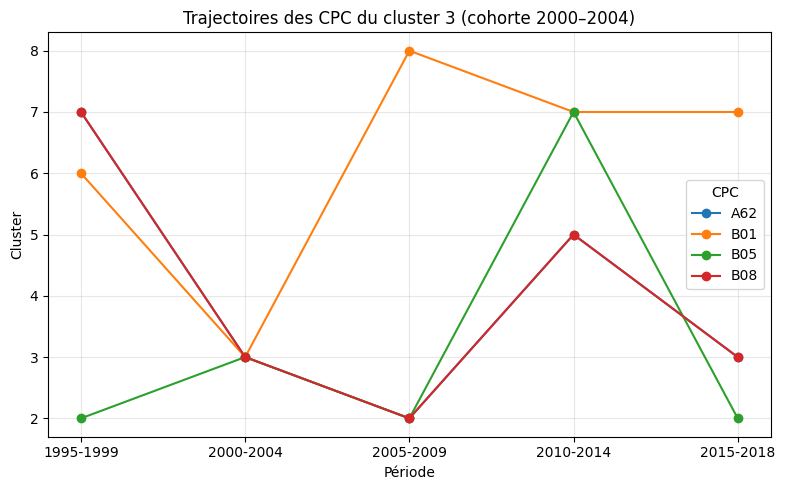

In [33]:
import matplotlib.pyplot as plt

# Trajectoires des CPC du cluster 3 (cohorte 2000-2004)
trajectoires_cluster_3 = {
    "A62": [7, 3, 2, 5, 3],
    "B01": [6, 3, 8, 7, 7],
    "B05": [2, 3, 2, 7, 2],
    "B08": [7, 3, 2, 5, 3],
}

periods = ["1995-1999", "2000-2004", "2005-2009", "2010-2014", "2015-2018"]

plt.figure(figsize=(8, 5))

for cpc, clusters in trajectoires_cluster_3.items():
    plt.plot(periods, clusters, marker="o", label=cpc)

plt.xlabel("Période")
plt.ylabel("Cluster")
plt.title("Trajectoires des CPC du cluster 3 (cohorte 2000–2004)")
plt.legend(title="CPC")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Le cluster 3 est donc un cluster de transition technologique associé à une phase de recombinaison des connaissances, situé entre des clusters plus spécialisés et plus stables

In [34]:
import pandas as pd
import plotly.graph_objects as go

# Données : trajectoires des CPC du cluster 3
data = [
    ("A62", "1995-1999", 7),
    ("A62", "2000-2004", 3),
    ("A62", "2005-2009", 2),
    ("A62", "2010-2014", 5),
    ("A62", "2015-2018", 3),

    ("B01", "1995-1999", 6),
    ("B01", "2000-2004", 3),
    ("B01", "2005-2009", 8),
    ("B01", "2010-2014", 7),
    ("B01", "2015-2018", 7),

    ("B05", "1995-1999", 2),
    ("B05", "2000-2004", 3),
    ("B05", "2005-2009", 2),
    ("B05", "2010-2014", 7),
    ("B05", "2015-2018", 2),

    ("B08", "1995-1999", 7),
    ("B08", "2000-2004", 3),
    ("B08", "2005-2009", 2),
    ("B08", "2010-2014", 5),
    ("B08", "2015-2018", 3),
]

df = pd.DataFrame(data, columns=["cpc", "period", "cluster"])


In [35]:
# Création des transitions entre périodes consécutives
flows = []

for cpc in df["cpc"].unique():
    sub = df[df["cpc"] == cpc].sort_values("period")
    for i in range(len(sub) - 1):
        flows.append({
            "source": f"{sub.iloc[i]['period']} | C{sub.iloc[i]['cluster']}",
            "target": f"{sub.iloc[i+1]['period']} | C{sub.iloc[i+1]['cluster']}",
            "value": 1
        })

flows_df = pd.DataFrame(flows)


In [36]:
# Liste des noeuds
labels = list(pd.unique(flows_df[["source", "target"]].values.ravel()))
label_to_index = {label: i for i, label in enumerate(labels)}

# Indexation
sources = flows_df["source"].map(label_to_index)
targets = flows_df["target"].map(label_to_index)
values = flows_df["value"]

# Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=15,
        line=dict(color="black", width=0.5),
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])

fig.update_layout(
    title="Alluvial plot des trajectoires des CPC du cluster 3",
    font_size=10
)

fig.show()


On construit une fonction qui automatise la construction d'un alluvial plot pour n'importe quel cluster.

In [37]:
import pandas as pd
import plotly.graph_objects as go

def alluvial_cluster_trajectories(
    cluster_time_df,
    cluster_id,
    reference_period="2000-2004"
):
    """
    Alluvial plot des trajectoires des CPC appartenant à un cluster donné
    à une période de référence.
    """

    # 1. CPC appartenant au cluster à la période de référence
    cpc_cohort = cluster_time_df.loc[
        (cluster_time_df["cluster"] == cluster_id) &
        (cluster_time_df["period"] == reference_period),
        "cpc"
    ].unique()

    df = cluster_time_df[cluster_time_df["cpc"].isin(cpc_cohort)].copy()

    # 2. Ordre temporel des périodes
    period_order = sorted(df["period"].unique())
    df["period"] = pd.Categorical(
        df["period"],
        categories=period_order,
        ordered=True
    )

    df = df.sort_values(["cpc", "period"])

    # 3. Construction des flux
    flows = []

    for cpc, sub in df.groupby("cpc"):
        sub = sub.sort_values("period")
        for i in range(len(sub) - 1):
            flows.append({
                "source": f"{sub.iloc[i]['period']} | C{sub.iloc[i]['cluster']}",
                "target": f"{sub.iloc[i+1]['period']} | C{sub.iloc[i+1]['cluster']}",
                "value": 1
            })

    flows_df = pd.DataFrame(flows)

    # 4. Noeuds du Sankey
    labels = list(pd.unique(flows_df[["source", "target"]].values.ravel()))
    label_to_index = {label: i for i, label in enumerate(labels)}

    # 5. Sankey plot
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=15,
            line=dict(color="black", width=0.5),
            label=labels
        ),
        link=dict(
            source=flows_df["source"].map(label_to_index),
            target=flows_df["target"].map(label_to_index),
            value=flows_df["value"]
        )
    )])

    fig.update_layout(
        title=f"Alluvial plot des trajectoires des CPC du cluster {cluster_id}",
        font_size=10
    )

    fig.show()


In [38]:
#alluvial_cluster_trajectories(cluster_time_df, 7)
#alluvial_cluster_trajectories(cluster_time_df, 2)


!! à pondérer par le nb de brevets

Ensuite, on veut regarder la stabilité du cluster 3 en s'intéressant à la part des CPC qui restent dans le même cluster

In [39]:
stability = (
    traj_cluster_3
    .groupby("period")["cluster"]
    .apply(lambda x: (x == 3).mean())
    .reset_index(name="share_still_in_cluster_3")
)

stability


,period,share_still_in_cluster_3


- si la stabilité est proche de 1, on a un cluster stable, et donc potentiellement une nouvelle discipline installée. 

- si la stabilité baisse, alors le cluster se recompose, c'était une phase expérimentale.

- si la stabilité augmente, le cluster est attracteur  et émergent

On veut maintenant construire un indice de convergence. Pour chaque cluster cible 
𝑘 et période t, on regarde :
- d’où viennent les CPC
- à quel point les sources sont diversifiées

In [40]:
import numpy as np

def convergence_index(transitions_df):
    """
    Calcule un indice de convergence basé sur l'entropie
    des flux entrants par cluster et période.
    """
    
    df = transitions_df.copy()
    
    # Part des flux par source
    df["p"] = (
        df["count"] /
        df.groupby(["period_to", "cluster_t1"])["count"].transform("sum")
    )
    
    # Entropie
    conv = (
        df
        .groupby(["period_to", "cluster_t1"])
        .apply(lambda x: -(x["p"] * np.log(x["p"])).sum())
        .reset_index(name="convergence_index")
    )
    
    return conv


In [41]:
conv_index_df = convergence_index(transitions_df)
conv_index_df.sort_values("convergence_index", ascending=False).head(10)


/tmp/ipykernel_102359/342423518.py:21: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,period_to,cluster_t1,convergence_index
248,2006-2007,3,1.706057
353,2016-2017,8,1.639706
288,2010-2011,3,1.630433
192,2000-2001,7,1.577917
49,1986-1987,4,1.549826
333,2014-2015,8,1.503461
37,1985-1986,2,1.498740
171,1998-1999,6,1.463236
2,1981-1982,2,1.448004
313,2012-2013,8,1.428551


Plus l'indice est élevé, plus il y a convergence. L'indice augmente quand il y a bcp de clusters sources. Il est indépendant du nombre de CPC et est comparable dans le temps.

Le pb avec le cluster 3 c'est qu'il n'est pas stable après la période étudiée. On peut donc dire que c'est un cluster de recombinaison, caractérisé par une forte instabilité et une dispersion ultérieure des CPC. Alors que nous on voudrait identifier des clusters d’absorption, qui agrègent durablement des technologies issues de plusieurs domaines. Seuls ces derniers peuvent être interprétés comme l’émergence de nouveaux champs technologiques.

On dira qu’un cluster c est absorbeur à la période t si :

1) Diversité des entrées élevée
Il reçoit des CPC provenant de plusieurs clusters à t−1

2) Stabilité après absorption

Les CPC qui entrent restent majoritairement dans le cluster

On construit d'abord les transitions inter-clusters

In [42]:
df = cluster_time_df.copy()

# Ordre temporel
period_order = sorted(df["period"].unique())
df["period"] = pd.Categorical(df["period"], categories=period_order, ordered=True)

df = df.sort_values(["cpc", "period"])

# Transitions
transitions = []

for cpc, sub in df.groupby("cpc"):
    sub = sub.sort_values("period")
    for i in range(len(sub) - 1):
        transitions.append({
            "cpc": cpc,
            "period_t": sub.iloc[i]["period"],
            "period_t1": sub.iloc[i+1]["period"],
            "cluster_t": sub.iloc[i]["cluster"],
            "cluster_t1": sub.iloc[i+1]["cluster"],
        })

transitions_df = pd.DataFrame(transitions)


Ensuite, on mesure la diversité des entrées (étape1)

In [43]:
def entropy(p):
    p = p[p > 0]
    return -np.sum(p * np.log(p))

inflow_stats = (
    transitions_df
    .groupby(["period_t1", "cluster_t1"])["cluster_t"]
    .value_counts(normalize=True)
    .rename("p")
    .reset_index()
)

inflow_entropy = (
    inflow_stats
    .groupby(["period_t1", "cluster_t1"])["p"]
    .apply(entropy)
    .reset_index(name="H_in")
)


Si H_in est élevé, il y a bcp de clusters différents en entrée.

Puis on mesure la stabilité après entrée (étape 2). En fait on mesure la probabilité qu’un CPC reste dans le cluster au pas suivant.

In [54]:
# Persistance : P(c_t+2 = c | c_t+1 = c)
persistence = (
    transitions_df
    .groupby(["period_t", "cluster_t"])
    .apply(lambda x: np.mean(x["cluster_t1"] == x["cluster_t"]))
    .reset_index(name="persistence")
)

transitions_df

/tmp/ipykernel_102359/2781133274.py:5: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,cpc,period_t,period_t1,cluster_t,cluster_t1
0,A01,1980-1981,1981-1982,4,3
1,A01,1981-1982,1982-1983,3,4
2,A01,1982-1983,1983-1984,4,4
3,A01,1983-1984,1984-1985,4,9
4,A01,1984-1985,1985-1986,9,7
...,...,...,...,...,...
4868,Y10,2013-2014,2014-2015,1,5
4869,Y10,2014-2015,2015-2016,5,8
4870,Y10,2015-2016,2016-2017,8,5
4871,Y10,2016-2017,2017-2018,5,3


In [45]:
# puis on décale pour comparer
persistence["period"] = persistence["period_t"]
persistence = persistence[["period", "cluster_t", "persistence"]]
persistence.columns = ["period", "cluster", "persistence"]

persistence["period"]

0      1980-1981
1      1980-1981
2      1980-1981
3      1980-1981
4      1980-1981
         ...    
375    2017-2018
376    2017-2018
377    2017-2018
378    2017-2018
379    2017-2018
Name: period, Length: 380, dtype: object

Puis on identifie les clusters absorbants

In [ ]:
absorption_df = (
    inflow_entropy
    .merge(
        persistence,
        left_on=["period_t1", "cluster_t1"],
        right_on=["period", "cluster"],
        how="left"
    )
    .drop(columns=["period", "cluster"])
)

absorption_df = absorption_df.rename(columns={
    "period_t1": "period",
    "cluster_t1": "cluster"
})


On def un score d'absorption

In [ ]:
absorption_df["absorption_score"] = (
    absorption_df["H_in"] * absorption_df["persistence"]
)


,period,cluster,H_in,persistence,absorption_score,convergence_simple,convergence_2periods,convergence_nperiods
0,1981-1982,0,0.348832,0.888889,0.310073,False,False,False
1,1981-1982,1,0.951488,0.000000,0.000000,True,False,False
2,1981-1982,2,1.448004,0.214286,0.310287,True,False,False
3,1981-1982,3,0.955700,0.000000,0.000000,True,False,False
4,1981-1982,5,-0.000000,0.000000,-0.000000,False,False,False
...,...,...,...,...,...,...,...,...
370,2018-2019,5,1.018074,NaN,NaN,False,False,False
371,2018-2019,6,0.943348,NaN,NaN,False,False,False
372,2018-2019,7,0.900256,NaN,NaN,False,False,False
373,2018-2019,8,1.399789,NaN,NaN,False,False,False


In [48]:
# Seuils simples (à discuter ensuite)
H_threshold = absorption_df["H_in"].quantile(0.40)
P_threshold = absorption_df["persistence"].quantile(0.40)

absorption_df["convergence_simple"] = (
    (absorption_df["H_in"] >= H_threshold) &
    (absorption_df["persistence"] >= P_threshold)
)

#absorption_df = absorption_df.sort_values(["period", "cluster"])
#print(absorption_df)

absorption_df["convergence_2periods"] = (
    absorption_df["convergence_simple"] &
    absorption_df.groupby("cluster")["convergence_simple"].shift(1)
)

absorbing_clusters = absorption_df[
    absorption_df["convergence_2periods"]
]


#absorption_df[(absorption_df["period"]=="1993-1994")]["convergence_2periods"]
#print(absorption_df)



In [49]:
def consecutive_convergence(df, n):
    group = df.groupby("cluster")["convergence_simple"]
    
    condition = df["convergence_simple"].copy()
    
    for i in range(1, n):
        condition &= group.shift(i)
    
    return condition

absorption_df["convergence_nperiods"] = consecutive_convergence(absorption_df, 5)

absorption_df[(absorption_df["convergence_nperiods"])][["period","cluster"]]

,period,cluster
37,1985-1986,2
66,1988-1989,1
70,1988-1989,5
76,1989-1990,1
86,1990-1991,1
96,1991-1992,1
97,1991-1992,2
98,1991-1992,3
106,1992-1993,1
107,1992-1993,2


In [ ]:
def classement_clusters(df, max_n=15):
    '''
     Entrée
    df : DataFrame
    max_n : entier -> nombre max de périodes sur lesquelles la stabilité des clusters est analysée

    Sortie
    classement : classement des clusters ayant la période de stabilité la plus longue
    '''
    clusters=df["cluster"].unique()   
    durees_max={c : 0 for c in clusters}
    fin_stabilité = {c: None for c in clusters}

    for i in range(1,max_n+1):

        cond=consecutive_convergence(df,i)
        clusters_duree_i=absorption_df.loc[cond,"cluster"].unique()

        for c in clusters_duree_i :
            durees_max[c]=i
            fin_stabilité[c] = df.loc[cond & (df["cluster"] == c), "period"].iloc[-1]
    
    classement = (
        pd.DataFrame({
            "cluster": list(durees_max.keys()),
            "stabilité maximale": list(durees_max.values()),
            "fin de la stabilité": list(fin_stabilité.values()),
        })
        .sort_values("stabilité maximale", ascending=False)
    )

    return classement

print(classement_clusters(absorption_df))

   cluster  stabilité maximale fin de la stabilité
1        1                  14           1997-1998
2        2                  10           1996-1997
5        7                   9           2003-2004
7        4                   7           1994-1995
6        8                   7           2017-2018
8        6                   6           2002-2003
4        5                   6           2009-2010
3        3                   5           2010-2011
0        0                   4           2000-2001
9        9                   4           2013-2014


In [58]:
def cluster_recompose(cluster,debut,fin, seuil=0.8):
    '''
    Entree
    cluster : entier entre 0 et 9 -> cluster dont on veut étudier la recomposition
    debut : entier -> debut de la période sur laquelle on veut étudier la recomposition du cluster
    fin : entier -> fin de cette période

    Sortie : 

    bool


    Règle utilisée pour déterminer si un cluster se recompose ou non entre t et t+k (à discuter) :
    au moins 80% des CPC en t+k n'étaient pas présents en t

    '''
    cpc_debut = set(
        transitions_df[
            (transitions_df["period_t"] == debut) &
            (transitions_df["cluster_t"] == cluster)
        ]["cpc"]
    )

    cpc_fin = set(
        transitions_df[
            (transitions_df["period_t1"] == fin) &
            (transitions_df["cluster_t1"] == cluster)
        ]["cpc"]
    )

    nouveaux = cpc_fin - cpc_debut
    renouvellement = len(nouveaux) / len(cpc_fin)

    return (renouvellement >= seuil)

print(cluster_recompose(0,"1984-1985","2007-2008"))
print(cluster_recompose(1,"1991-1992","1994-1995"))


True
False


In [52]:
cluster_time_df[
    (cluster_time_df["period"]=="1993-1994") & 
    (cluster_time_df["cluster"]==0)
    ]["cpc"].unique()




array(['B22', 'B81', 'B82', 'C04', 'C23', 'C25', 'C30', 'F21', 'G02',
       'H02', 'H05', 'H10'], dtype=object)